In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120})

DATA_DIR = Path("../data")
if not DATA_DIR.exists():
    DATA_DIR = Path("Durga/Lab/MLDL/data")

pd.set_option("display.max_columns", 120)

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from matplotlib.patches import Rectangle
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(RANDOM_STATE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

CLASS_COLORS = np.array(
    [
        [1.0, 0.15, 0.15],
        [0.1, 0.7, 0.25],
        [0.15, 0.3, 1.0],
    ],
    dtype="float32",
)

def make_detection_data(n=640, size=64, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    images = np.zeros((n, 3, size, size), dtype="float32")
    boxes = np.zeros((n, 4), dtype="float32")
    labels = np.zeros(n, dtype="int64")
    for i in range(n):
        cls = rng.integers(0, len(CLASS_COLORS))
        w = rng.integers(size // 6, size // 3)
        h = rng.integers(size // 6, size // 3)
        x1 = rng.integers(2, size - w - 2)
        y1 = rng.integers(2, size - h - 2)
        x2 = x1 + w
        y2 = y1 + h
        images[i, :, y1:y2, x1:x2] = CLASS_COLORS[cls, :, None, None]
        images[i] += rng.normal(0, 0.02, images[i].shape).astype("float32")
        images[i] = np.clip(images[i], 0, 1)
        boxes[i] = [x1 / size, y1 / size, x2 / size, y2 / size]
        labels[i] = cls
    return images, boxes, labels

images, boxes, labels = make_detection_data()
train_images, test_images = images[:512], images[512:]
train_boxes, test_boxes = boxes[:512], boxes[512:]
train_labels, test_labels = labels[:512], labels[512:]

train_loader = DataLoader(
    TensorDataset(torch.tensor(train_images), torch.tensor(train_boxes), torch.tensor(train_labels)),
    batch_size=64,
    shuffle=True,
)

Device: cpu


/home/durgaumadev/security-for-data-science-lab/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
class TinySSD(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
        )
        self.class_head = nn.Linear(64, num_classes)
        self.box_head = nn.Sequential(nn.Linear(64, 4), nn.Sigmoid())

    def forward(self, x):
        features = self.backbone(x)
        return self.class_head(features), self.box_head(features)

model = TinySSD().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(10):
    model.train()
    total_loss = 0
    for batch_images, batch_boxes, batch_labels in train_loader:
        batch_images = batch_images.to(device)
        batch_boxes = batch_boxes.to(device)
        batch_labels = batch_labels.to(device)
        class_logits, pred_boxes = model(batch_images)
        loss_cls = F.cross_entropy(class_logits, batch_labels)
        loss_box = F.smooth_l1_loss(pred_boxes, batch_boxes)
        loss = loss_cls + 5.0 * loss_box
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(batch_labels)
    print(f"epoch {epoch + 1}: loss={total_loss / len(train_loader.dataset):.4f}")

epoch 1: loss=1.2340


epoch 2: loss=1.1865


epoch 3: loss=1.1012


epoch 4: loss=0.9551


epoch 5: loss=0.7260


epoch 6: loss=0.4929


epoch 7: loss=0.3114


epoch 8: loss=0.1916


epoch 9: loss=0.1355


epoch 10: loss=0.1160


Class accuracy: 1.000
Mean absolute box error: 0.177


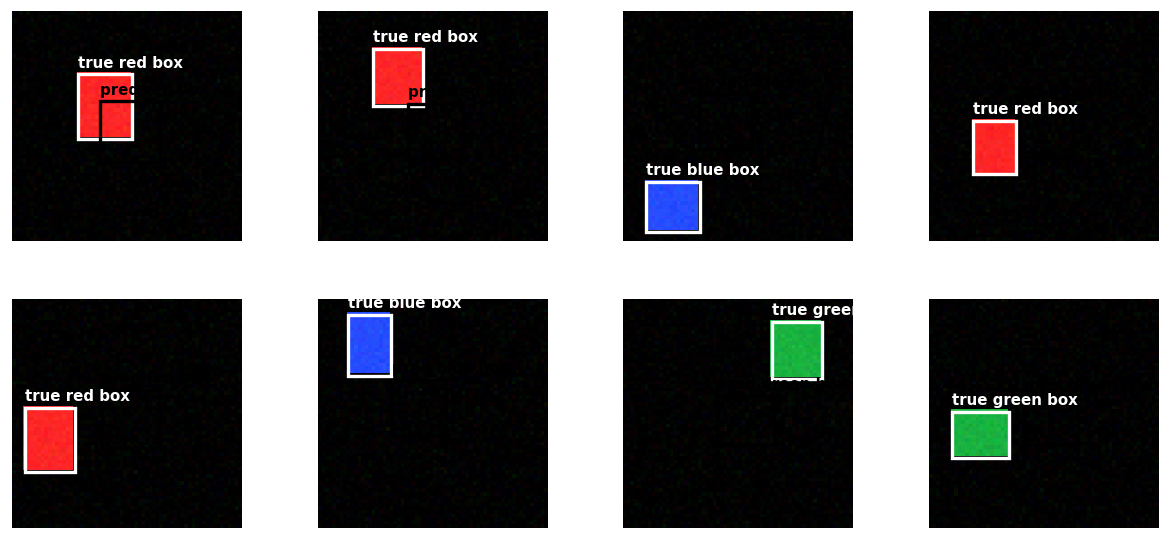

In [4]:
def draw_box(ax, box, color, label):
    size = 64
    x1, y1, x2, y2 = box * size
    ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor=color, linewidth=2))
    ax.text(x1, max(0, y1 - 2), label, color=color, fontsize=9, weight="bold")

model.eval()
with torch.no_grad():
    test_tensor = torch.tensor(test_images, device=device)
    logits, pred_boxes = model(test_tensor)
    pred_labels = logits.argmax(dim=1).cpu().numpy()
    pred_boxes = pred_boxes.cpu().numpy()

class_acc = (pred_labels == test_labels).mean()
mean_box_error = np.abs(pred_boxes - test_boxes).mean()
print(f"Class accuracy: {class_acc:.3f}")
print(f"Mean absolute box error: {mean_box_error:.3f}")

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
names = ["red box", "green box", "blue box"]
for ax, image, true_box, true_label, pred_box, pred_label in zip(
    axes.ravel(), test_images[:8], test_boxes[:8], test_labels[:8], pred_boxes[:8], pred_labels[:8]
):
    ax.imshow(np.moveaxis(image, 0, -1))
    draw_box(ax, true_box, "white", f"true {names[true_label]}")
    draw_box(ax, pred_box, "black", f"pred {names[pred_label]}")
    ax.axis("off")
plt.tight_layout()
plt.show()